In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision

from maskvar.models.vqvae_single import VQVAE_Single
from maskvar.maskseg_build_everything import build_vqvae_single_5_stages_v1
from maskvar.datasets import (
    HQSeg44KTestDataset,
    HQSeg44KTrainDataset,
    MaskLevelDatasetDummy,
    LvisDataset,
)
from maskvar.utils.metrics import calc_iou

In [2]:
# checkpoint_path = 'ckpt/vqvae_single_epoch_32.pth'
# checkpoint_path = 'out_vqvae_fewer_stages1/ckpt/vqvae_single_epoch_40.pth'
# checkpoint_path = '../out/out_vqvae_4_stages_2/ckpt/vqvae_single_epoch_180.pth'
checkpoint_path = '../out/out_vqvae_5_stages_v1/ckpt/vqvae_single_epoch_50.pth'
device = 'cuda'

In [3]:
# 创建数据加载器
# dataset = HQSeg44KTrainDataset(data_root='datasets/sam-hq')
dataset = HQSeg44KTrainDataset(data_root='../data/sam-hq')
mask_level_dataset = MaskLevelDatasetDummy(
    dataset,
    sam_encoder=None,
    with_image_embed=False,
    device=device,
    mask_filter_thresh=0.1,
    seed=42,
)

In [4]:
vqvae = build_vqvae_single_5_stages_v1(checkpoint_path).to(device)
vqvae = vqvae.eval()

In [5]:
def visualize(item, device='cpu'):
    image, _, single_mask_normalized, single_mask = item

    # result = vqvae.img_to_reconstructed_img(mask.to(DEVICE).unsqueeze(0))
    indices = vqvae.img_to_idxBl(single_mask_normalized.to(device).unsqueeze(0))
    result = vqvae.idxBl_to_img(indices, same_shape=True)
    var_input = vqvae.quantize.idxBl_to_var_input(indices)

    print(var_input.shape)

    for i in range(len(indices)):
        print(f'index {i}: {indices[i].shape}')
    # result_conv = [edge(item) for item in result]
    result = [mask / 2 + 0.5 for mask in result]
    chw = torchvision.utils.make_grid(torch.cat([torch.cat(result[1:], dim=0), single_mask.to(device).unsqueeze(0)], dim=0), nrow=3, 
    padding=1, pad_value=1.0)

    print(single_mask.shape, result[-1].shape)

    iou = calc_iou(result[-1], single_mask.to(device).unsqueeze(0))
    print(f'iou: {iou}')
    chw = chw.permute(1, 2, 0).mul_(255).cpu().numpy()
    chw = Image.fromarray(chw.astype(np.uint8))
    return chw

In [6]:
data_sample = next(iter(mask_level_dataset))

torch.Size([1, 897, 32])
index 0: torch.Size([1, 1])
index 1: torch.Size([1, 64])
index 2: torch.Size([1, 256])
index 3: torch.Size([1, 576])
index 4: torch.Size([1, 1024])
torch.Size([1, 256, 256]) torch.Size([1, 1, 256, 256])
iou: tensor([0.9996], device='cuda:0')


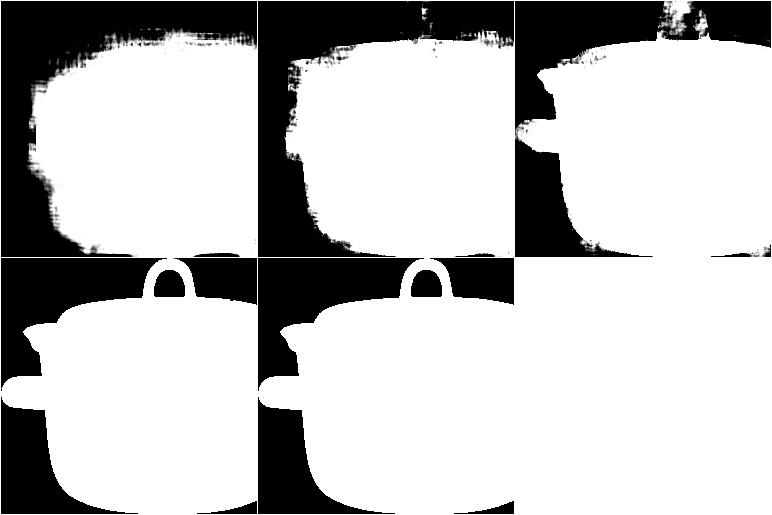

In [7]:
# visualize(dataset[233], device=device)
visualize(data_sample, device=device)